# Modeling

Проверим, улучшает ли модель (Ridge) наивный бейзлайн lag_7.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

project_root

WindowsPath('C:/Projects/guest-predictor')

In [3]:
from src.data import PROCESSED_PATH, RAW_PATH, load_raw, prepare_daily_data, save_processed
from src.features import drop_rows_without_history, make_features
from src.model import FEATURE_COLUMNS, TARGET_COLUMN, predict_model, save_model, train_model
from src.validation import calculate_metrics, evaluate_baseline, metrics_to_frame, time_split

In [4]:
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 80)

## Подготовка данных

Данные подготавливаются из raw-датасета теми же функциями, которые лежат в src. Так эксперимент можно воспроизвести от исходного датасета до модели

In [5]:
raw = load_raw(project_root / RAW_PATH)
dataset = prepare_daily_data(raw)
processed = dataset.frame

save_processed(dataset, project_root / PROCESSED_PATH)

processed.head()

,date,restaurant_id,guests,revenue
0,2024-01-01,1,65,82908.0
1,2024-01-02,1,75,128446.0
2,2024-01-03,1,107,154598.0
3,2024-01-04,1,113,156028.0
4,2024-01-05,1,113,166075.0


In [6]:
pd.DataFrame(
    {
        "rows": [len(processed)],
        "min_date": [processed["date"].min()],
        "max_date": [processed["date"].max()],
        "restaurants": [processed["restaurant_id"].nunique()],
        "target": [dataset.target],
    }
)

,rows,min_date,max_date,restaurants,target
0,3012,2024-01-01,2026-09-30,3,guests


Видим, что для моделирования используется подготовленный непрерывный дневной ряд без пропусков.

## Генерация признаков

Используем календарные признаки, лаги 7/14/28 дней и скользящие средние сдвинутые на 7 дней. Такой набор доступен для всех дней недельного прогноза без подстановки будущих фактов.

In [7]:
features = make_features(processed, target=dataset.target)
features_with_history = drop_rows_without_history(features)

pd.DataFrame(
    {
        "rows_before_drop": [len(features)],
        "rows_after_drop": [len(features_with_history)],
        "removed_rows": [len(features) - len(features_with_history)],
    }
)

,rows_before_drop,rows_after_drop,removed_rows
0,3012,2910,102


In [8]:
list(FEATURE_COLUMNS)

['month',
 'is_holiday',
 'lag_7',
 'lag_14',
 'lag_28',
 'rolling_mean_7_lag_7',
 'rolling_mean_28_lag_7',
 'restaurant_id',
 'day_of_week']

In [9]:
features_with_history[
    ["date", "restaurant_id", TARGET_COLUMN, *FEATURE_COLUMNS]
].head()

,date,restaurant_id,guests,month,is_holiday,lag_7,lag_14,lag_28,rolling_mean_7_lag_7,rolling_mean_28_lag_7,restaurant_id,day_of_week
0,2024-02-04,1,120,2,0,113.0,102.0,107.0,87.714286,95.642857,1,6
1,2024-02-05,1,58,2,0,71.0,55.0,131.0,90.000000,95.857143,1,0
2,2024-02-06,1,57,2,0,61.0,80.0,57.0,87.285714,95.357143,1,1
3,2024-02-07,1,71,2,0,97.0,68.0,70.0,91.428571,95.000000,1,2
4,2024-02-08,1,85,2,0,100.0,80.0,99.0,94.285714,94.535714,1,3


Первые строки по каждому ресторану убираются, потому что для них ещё нет достаточной истории для лагов и скользящих средних.

## Разбиение по времени

Валидация берётся из последних 6 недель. Перемешивание не используется, потому что это временной ряд.

In [10]:
train, valid = time_split(features_with_history, valid_weeks=6)

pd.DataFrame(
    {
        "part": ["train", "valid"],
        "rows": [len(train), len(valid)],
        "min_date": [train["date"].min(), valid["date"].min()],
        "max_date": [train["date"].max(), valid["date"].max()],
    }
)

,part,rows,min_date,max_date
0,train,2784,2024-02-04,2026-08-19
1,valid,126,2026-08-20,2026-09-30


В train вошли данные до 2026-08-19 включительно, а в validation последние 42 дня, с 2026-08-20 по 2026-09-30. Временной порядок сохранён, модель обучается только на прошлом и оценивается на будущем периоде.

## Бейзлайн

Бейзлайн прогнозирует значение того же дня недели неделю назад, то есть использует lag_7

In [11]:
baseline_metrics = evaluate_baseline(valid, target=TARGET_COLUMN, prediction_column="lag_7")
baseline_metrics

{'mae': 20.142857142857142, 'mape': np.float64(0.3039579229467643)}

Наивный прогноз lag_7, который повторяет значение недельной давности, даёт MAE 20.14 гостя и MAPE 30.40% на validation периоде

## Ridge-модель

Обучим линейную модель через Pipeline. Числовые признаки масштабируются, категориальные признаки кодируются внутри пайплайна.

In [12]:
ridge_model = train_model(train, target=TARGET_COLUMN)
valid_predictions = predict_model(ridge_model, valid)

ridge_metrics = calculate_metrics(valid[TARGET_COLUMN], valid_predictions)
ridge_metrics

{'mae': 15.920844543428675, 'mape': np.float64(0.23445971858754336)}

## Сравнение метрик

In [13]:
metrics = metrics_to_frame(
    {
        "baseline_lag_7": baseline_metrics,
        "ridge": ridge_metrics,
    }
)

metrics["mae"] = metrics["mae"].round(2)
metrics["mape_percent"] = (metrics["mape"] * 100).round(2)
metrics = metrics.drop(columns="mape")

metrics

,model,mae,mape_percent
0,ridge,15.92,23.45
1,baseline_lag_7,20.14,30.40


In [14]:
baseline_mae = baseline_metrics["mae"]
ridge_mae = ridge_metrics["mae"]

pd.DataFrame(
    {
        "baseline_mae": [baseline_mae],
        "ridge_mae": [ridge_mae],
        "mae_delta": [ridge_mae - baseline_mae],
        "mae_relative_change_percent": [(ridge_mae / baseline_mae - 1) * 100],
    }
).round(2)

,baseline_mae,ridge_mae,mae_delta,mae_relative_change_percent
0,20.14,15.92,-4.22,-20.96


Ridge улучшает прогноз относительно недельного бейзлайна. MAE снизился с 20.14 до 15.92 гостя, то есть на 4.22 гостя или на 20.9%. MAPE также снизился с 30.40% до 23.45%.По таблице видно, что Ridge-модель дала небольшое реальное улучшение относительно простого недельного бейзлайна.

## Факт и прогноз

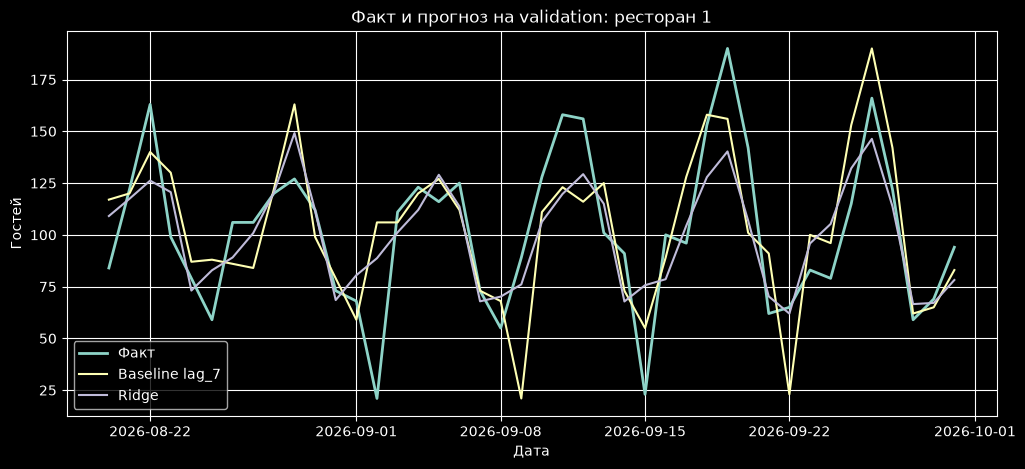

In [15]:
plot_restaurant_id = 1

plot_data = valid[valid["restaurant_id"].eq(plot_restaurant_id)].copy()
plot_data["ridge_prediction"] = valid_predictions.loc[plot_data.index]
plot_data["baseline_prediction"] = plot_data["lag_7"]

plt.plot(plot_data["date"], plot_data[TARGET_COLUMN], label="Факт", linewidth=2)
plt.plot(plot_data["date"], plot_data["baseline_prediction"], label="Baseline lag_7")
plt.plot(plot_data["date"], plot_data["ridge_prediction"], label="Ridge")

plt.title(f"Факт и прогноз на validation: ресторан {plot_restaurant_id}")
plt.xlabel("Дата")
plt.ylabel("Гостей")
plt.legend()
plt.show()

На графике Ridge в целом лучше повторяет уровень спроса, чем lag_7, но, как и бейзлайн, сглаживает отдельные резкие провалы и всплески.График помогает увидеть не только среднюю ошибку, но и то, как модель ведёт себя на провалах и всплесках.

## Ошибки прогноза

In [16]:
errors = valid[["date", "restaurant_id", TARGET_COLUMN, "lag_7"]].copy()

errors["ridge_prediction"] = valid_predictions
errors["baseline_prediction"] = errors["lag_7"]

errors["ridge_absolute_error"] = (
    errors[TARGET_COLUMN] - errors["ridge_prediction"]
).abs()

errors["baseline_absolute_error"] = (
    errors[TARGET_COLUMN] - errors["baseline_prediction"]
).abs()

In [17]:
top_errors = errors.sort_values("ridge_absolute_error", ascending=False).head(10).copy()

numeric_columns = top_errors.select_dtypes(include="number").columns
top_errors[numeric_columns] = top_errors[numeric_columns].round(2)

top_errors

,date,restaurant_id,guests,lag_7,ridge_prediction,baseline_prediction,ridge_absolute_error,baseline_absolute_error
941,2026-09-02,1,21,106.0,88.70,106.0,67.70,85.0
954,2026-09-15,1,23,55.0,75.67,55.0,52.67,32.0
958,2026-09-19,1,190,156.0,140.26,156.0,49.74,34.0
1920,2026-09-11,2,150,99.0,105.35,99.0,44.65,51.0
1900,2026-08-22,2,89,153.0,129.01,153.0,40.01,64.0
950,2026-09-11,1,158,123.0,119.75,123.0,38.25,35.0
930,2026-08-22,1,163,140.0,126.18,140.0,36.82,23.0
959,2026-09-20,1,142,101.0,106.90,101.0,35.10,41.0
1906,2026-08-28,2,142,124.0,107.83,124.0,34.17,18.0
2897,2026-09-18,3,46,102.0,79.71,102.0,33.71,56.0


Самые большие ошибки возникают в дни резких локальных изменений спроса, например в неожиданных провалах или всплесках. Такие ситуации нельзя надёжно предсказать только по историческим лагам и календарным признакам.

## Коэффициенты Ridge

In [18]:
preprocessor = ridge_model.named_steps["preprocessor"]
regressor = ridge_model.named_steps["model"]

coefficients = pd.DataFrame(
    {
        "feature": preprocessor.get_feature_names_out(),
        "coefficient": regressor.coef_,
    }
)

coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients.sort_values("abs_coefficient", ascending=False).head(15).round(3)

,feature,coefficient,abs_coefficient
10,categorical__day_of_week_0,-18.935,18.935
15,categorical__day_of_week_5,15.022,15.022
14,categorical__day_of_week_4,9.169,9.169
7,categorical__restaurant_id_1,7.023,7.023
2,numeric__lag_7,6.989,6.989
11,categorical__day_of_week_1,-6.952,6.952
4,numeric__lag_28,6.950,6.950
9,categorical__restaurant_id_3,-6.707,6.707
3,numeric__lag_14,5.889,5.889
16,categorical__day_of_week_6,3.406,3.406


Наиболее заметный вклад в прогноз дают день недели, ресторан и недельные лаги. Это согласуется с природой задачи, спрос зависит и от привычного ритма конкретной точки, и от значений в те же дни предыдущих недель.

## Сохранение модели

In [19]:
model_path = project_root / "models" / "ridge_model.joblib"
save_model(ridge_model, model_path)

model_path

WindowsPath('C:/Projects/guest-predictor/models/ridge_model.joblib')

## Вывод

Ridge-модель превзошла недельный бейзлайн на отложенных последних 6 неделях. MAE составил 15.92 гостя против 20.14 у lag_7. Для прогноза используются только признаки, доступные не позднее чем за 7 дней до прогнозируемой даты, поэтому модель применима для недельного горизонта. Основное ограничение это резкие разовые изменения спроса, без внешних данных модель склонна их сглаживать.